!/usr/bin/env python
coding: utf-8
# Round 2 Strategy: ATR Cross-Sectional Alpha

**Pipeline:**
1. Load data (features, universe, returns)
2. Cross-sectional z-score of ATR + clip outliers
3. Construct targets: forward log returns → strip beta → z-score
4. Train PyGAM with monotonic constraint
5. Generate portfolio weights (vol-scaled, dollar-neutral)
6. Backtest using QRT `utils.py`

In [1]:
import pandas as pd
import numpy as np
import os, sys
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('phase2_qrt_challenge/scripts'))
from utils import backtest_portfolio

DATA_DIR = 'stores'

# Prediction horizon (trading days)
H = 5

# Rolling beta window (QRT Guideline specifies 250 days)
BETA_WINDOW = 250

# Train/val split ratio
TRAIN_RATIO = 0.70

# Volatility lookback for position sizing
VOL_WINDOW = 20

# Z-score clip threshold
ZSCORE_CLIP = 3.0

# Target GMV in USD for enforcing QRT trading limits (local backtest assumption)
TARGET_GMV = 10_000_000



## 1. Load Data

In [2]:
import os
import pandas as pd

# Load features (MultiIndex: level 0 = indicator name, level 1 = ticker)
features_df = pd.read_parquet(os.path.join(DATA_DIR, 'features.parquet'))
atr = features_df['average_true_range']  # shape: (dates, tickers)

# Load universe mask (1 = in universe, 0 = out)
universe = pd.read_parquet(os.path.join(DATA_DIR, 'universe_5m.parquet'))

# Load returns
returns = pd.read_parquet(os.path.join(DATA_DIR, 'returns.parquet'))

# Align all three on common dates and tickers
common_dates = atr.index.intersection(universe.index).intersection(returns.index)
common_tickers = atr.columns.intersection(universe.columns).intersection(returns.columns)

# FIX: Explicitly sort the dates chronologically and tickers alphabetically
common_dates = common_dates.sort_values()
common_tickers = common_tickers.sort_values()

# Subset and cast
atr = atr.loc[common_dates, common_tickers].astype('float64')
universe = universe.loc[common_dates, common_tickers]
returns = returns.loc[common_dates, common_tickers].astype('float64')

print(f'Dates: {len(common_dates)}, Tickers: {len(common_tickers)}')
print(f'Date range: {common_dates[0].date()} → {common_dates[-1].date()}')

Dates: 4117, Tickers: 4999
Date range: 2010-01-04 → 2026-05-15


## 2. Feature Engineering: 4-Factor Model

In [3]:
import numpy as np
import pandas as pd
# Loading Adj Close and Volume for Feature Engineering
print("Loading price and volume data...")
pv = pd.read_pickle('top_5000_yf_data.pkl')
adj_close = pv['Adj Close'][common_tickers].loc[common_dates].astype('float64')
volume = pv['Volume'][common_tickers].loc[common_dates].astype('float64')
print("Calculating Volatility...")
# 1. Realized Volatility (20 days) -> Cross-sectional Z-score
# Upgraded to use log returns for stricter mathematical stability
log_returns_df = np.log(adj_close / adj_close.shift(1))
vol_20d = log_returns_df.rolling(20).std()
vol_20d_masked = vol_20d.where(universe == 1)
vol_z = vol_20d_masked.sub(vol_20d_masked.mean(axis=1), axis=0).div(vol_20d_masked.std(axis=1), axis=0)
vol_z = vol_z.replace([np.inf, -np.inf], np.nan).clip(-ZSCORE_CLIP, ZSCORE_CLIP)
print("Calculating RSI...")
# 2. RSI (14 days) -> Cross-sectional rank
# Fixed: Using Wilder's Exponential Smoothing instead of Simple Moving Average
delta = adj_close.diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
# com=13 is mathematically equivalent to Wilder's alpha=1/14
roll_gain = gain.ewm(com=13, min_periods=14).mean()
roll_loss = loss.ewm(com=13, min_periods=14).mean()
# Calculate RS and handle division by zero safely
rs = roll_gain / roll_loss.replace(0, np.nan)
rsi = 100 - (100 / (1 + rs))
rsi = rsi.fillna(100)  # If loss was exactly 0, RSI maxes out at 100
rsi_masked = rsi.where(universe == 1)
rsi_rank = rsi_masked.rank(axis=1, pct=True)
print("Calculating Relative Volume...")
# 3. Relative Volume (today / 20-day avg)
rel_vol = volume / volume.rolling(20).mean()
rel_vol_masked = rel_vol.where(universe == 1)
rel_vol_masked = rel_vol_masked.replace([np.inf, -np.inf], np.nan).clip(0, 10)
print("Stacking features...")
stacked_features = pd.concat({
    'volatility': vol_z.stack(),
    'rsi': rsi_rank.stack(),
    'rel_volume': rel_vol_masked.stack()
}, axis=1)
print(f"Features stacked. Shape: {stacked_features.shape}")

Loading price and volume data...
Calculating Volatility...
Calculating RSI...
Calculating Relative Volume...
Stacking features...
Features stacked. Shape: (7426164, 3)


## 3. Target Construction

In [4]:

# h-day forward log return: ln(P_{t+h} / P_t)
fwd_log_ret = np.log(adj_close.shift(-H) / adj_close)

print('Downloading SPY data for benchmark...')
spy_data = yf.download('SPY', start=common_dates[0], end=common_dates[-1] + pd.Timedelta(days=10), progress=False)

if isinstance(spy_data.columns, pd.MultiIndex):
    if 'Adj Close' in spy_data.columns.levels[0]:
        spy_close = spy_data['Adj Close', 'SPY']
    else:
        spy_close = spy_data['Close', 'SPY']
else:
    spy_close = spy_data.get('Adj Close', spy_data['Close'])

spy_close = spy_close.reindex(common_dates).ffill().squeeze()

# Both market and stock daily returns MUST be log returns for the beta calculation
market_ret = np.log(spy_close / spy_close.shift(1))
daily_log_returns = np.log(adj_close / adj_close.shift(1))
returns_masked = daily_log_returns.where(universe == 1)

print('Computing rolling betas using 250-day window and QRT formula (Vectorized)...')

# 1. Sample Variance of the Market
rolling_var_m = market_ret.rolling(BETA_WINDOW, min_periods=120).var()

# 2. Sample Covariance (Properly aligned with variance degrees of freedom)
# This calculates the covariance between every stock column and the 1D market series simultaneously
roll_cov = returns_masked.rolling(BETA_WINDOW, min_periods=120).cov(market_ret)

# 3. Calculate Beta
raw_beta = roll_cov.div(rolling_var_m, axis=0)
betas = 0.2 + 0.8 * raw_beta

# 4. Generate Residual Forward Returns (Alpha)
fwd_market_ret = market_ret.rolling(H).sum().shift(-H)
residual_fwd_ret = fwd_log_ret.sub(betas.mul(fwd_market_ret, axis=0))

# 5. Cross-Sectional Z-Score target
residual_fwd_ret_masked = residual_fwd_ret.where(universe == 1)
target_mean = residual_fwd_ret_masked.mean(axis=1)
target_std = residual_fwd_ret_masked.std(axis=1)

Y = residual_fwd_ret_masked.sub(target_mean, axis=0).div(target_std, axis=0)
Y = Y.clip(-ZSCORE_CLIP, ZSCORE_CLIP)

# Stack Target and combine with features
stacked_Y = Y.stack()
stacked_data = stacked_features.copy()
stacked_data['target'] = stacked_Y
print(f"Target stacked. Final combined shape: {stacked_data.shape}")

Computing rolling betas using 250-day window and QRT formula (Vectorized)...
Target stacked. Final combined shape: (7426164, 4)


## 4. Model Training: PyGAM

In [5]:
from pygam import LinearGAM, s, te
import matplotlib.pyplot as plt
print("Splitting data into Train (2010-2020) and Test (2021+)...")
clean_data = stacked_data.dropna()
train_mask = (clean_data.index.get_level_values(0).year >= 2010) & (clean_data.index.get_level_values(0).year <= 2020)
val_mask = clean_data.index.get_level_values(0).year > 2020
train_data = clean_data[train_mask]
val_data = clean_data[val_mask]
# Note: Removed 'momentum' column. Features are now:
# 0: volatility, 1: rsi, 2: rel_volume
X_train = train_data[['volatility', 'rsi', 'rel_volume']].values
Y_train = train_data['target'].values
# MAX_SAMPLES = 500000
# if len(X_train) > MAX_SAMPLES:
#     idx = np.random.choice(len(X_train), MAX_SAMPLES, replace=False)
#     X_train = X_train[idx]
#     Y_train = Y_train[idx]
#     print(f"Subsampled to {MAX_SAMPLES}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(val_data)}")
# Updated GAM formula to drop momentum and adjust indices
gam = LinearGAM(
    s(0, constraints='monotonic_dec', n_splines=10) +  # Volatility (Penalty)
    te(1, 2, n_splines=(8, 8))                         # RSI x Rel_Volume (Interaction)
)
lam_space = np.logspace(1, 5, 10) 
print("Fitting GAM via Gridsearch (this may take a moment)...")
gam.gridsearch(X_train, Y_train, lam=lam_space, progress=True)
print(f'\nOptimal Lambda chosen: {gam.lam}')
print(f'Pseudo R-Squared: {gam.statistics_["pseudo_r2"]["explained_deviance"]:.6f}')


Splitting data into Train (2010-2020) and Test (2021+)...


  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Training samples: 3697046
Validation samples: 3072815
Fitting GAM via Gridsearch (this may take a moment)...


 10% (1 of 10) |##                       | Elapsed Time: 0:02:40 ETA:   0:24:07
 20% (2 of 10) |#####                    | Elapsed Time: 0:04:01 ETA:   0:16:06
 30% (3 of 10) |#######                  | Elapsed Time: 0:05:31 ETA:   0:12:53
 40% (4 of 10) |##########               | Elapsed Time: 0:06:53 ETA:   0:10:20
 50% (5 of 10) |############             | Elapsed Time: 0:08:44 ETA:   0:08:44
 60% (6 of 10) |###############          | Elapsed Time: 0:10:51 ETA:   0:07:14
 70% (7 of 10) |#################        | Elapsed Time: 0:12:37 ETA:   0:05:24
 80% (8 of 10) |####################     | Elapsed Time: 0:14:06 ETA:   0:03:31
 90% (9 of 10) |######################   | Elapsed Time: 0:15:30 ETA:   0:01:43
100% (10 of 10) |########################| Elapsed Time: 0:16:53 Time:  0:16:53



Optimal Lambda chosen: [[np.float64(10.0)], [[np.float64(10.0)], [np.float64(10.0)]]]
Pseudo R-Squared: 0.000732


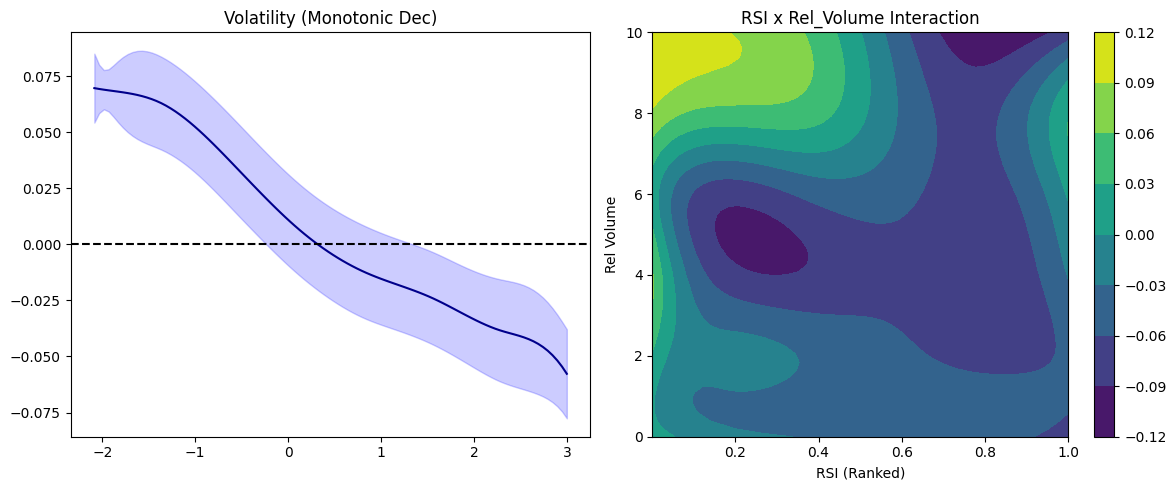

--- GAM Mathematical Formulation ---
[ 7.89256226e-02  6.78416052e-02  6.78416300e-02  3.79353764e-02
  5.34468671e-03 -1.43547664e-02 -2.17903346e-02 -4.15404307e-02
 -4.15403190e-02 -1.38663476e-01  3.33579706e-02  6.93066745e-02
  3.79609636e-01  5.92622431e-01  3.75935598e-01  2.39853739e-01
  1.51381966e-01  5.11435375e-02  2.25848331e-01 -3.40626084e-02
 -7.23769315e-02  2.52522363e-02 -9.87069153e-02  7.65256374e-02
  1.22734182e-01  4.34271492e-02  2.01821397e-01 -1.03398128e-01
  4.61740719e-02 -1.25835454e-01 -1.33618791e-01  7.52095786e-02
  1.10706978e-01  3.30274454e-02  1.50906411e-01 -8.12533872e-02
 -1.02506121e-02 -1.16306697e-01 -4.82881768e-02  8.03558678e-02
  7.57189666e-02 -5.03715076e-04 -6.22618508e-02 -3.32704544e-02
 -4.96460063e-02 -6.52381342e-02 -4.13146205e-02 -3.71807754e-02
 -5.89709044e-02 -8.41389329e-02 -2.05618470e-01  1.86241962e-02
 -9.79906317e-02 -1.05303571e-01 -9.72488649e-02 -8.90155495e-02
 -1.35134039e-01 -1.80296443e-01 -2.98457810e-01 -8.9

In [6]:
# =============================================================================
# --- GAM Learned Curve and Formulation ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Term 0: Volatility
XX = gam.generate_X_grid(term=0)
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)
axs[0].plot(XX[:, 0], pdep, color='darkblue')
axs[0].fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.2, color='blue')
axs[0].set_title('Volatility (Monotonic Dec)')
axs[0].axhline(0, color='black', linestyle='--')
# Term 1: RSI x Rel_Volume Interaction
XX = gam.generate_X_grid(term=1, n=50)
pdep = gam.partial_dependence(term=1, X=XX)
Z = pdep.reshape(50, 50)
# Note: RSI is index 1, Rel_Volume is index 2 in X
c = axs[1].contourf(XX[:, 1].reshape(50, 50), XX[:, 2].reshape(50, 50), Z, cmap='viridis')
fig.colorbar(c, ax=axs[1])
axs[1].set_title('RSI x Rel_Volume Interaction')
axs[1].set_xlabel('RSI (Ranked)')
axs[1].set_ylabel('Rel Volume')
plt.tight_layout()
plt.show()
# --- Extracting the Mathematical Equation ---
print("--- GAM Mathematical Formulation ---")
coefs = gam.coef_
print (coefs)
print(f"Number of coefficients (including intercept): {len(coefs)}")
print(f"Intercept: {coefs[-1]:.6f}")

## 5. Portfolio Construction

In [7]:
import numpy as np
import pandas as pd

# =============================================================================
# Pipeline:
#   1. Predict alpha using the trained GAM
#   2. Apply strict Liquidity Filter (ADV >= $5M)
#   3. Cross-sectionally regress the alpha on betas to extract the residual
#   4. Weight residual signal by inverse realized volatility (with math protections)
#   5. Conviction Threshold with Hysteresis -> Dollar-neutral Long/Short
# =============================================================================

# Parameters
VOL_WINDOW = 20
TARGET_GMV = 10_000_000
MIN_ADV_USD = 5_000_000

# Hysteresis Parameters (Tune these if needed)
ENTRY_THRESHOLD = 2.4  # Need a strong anomaly to enter (Pay the 2bps)
EXIT_THRESHOLD = 0.25   # Hold until the anomaly decays (Save on turnover)

print('Computing 60-day rolling ADV...')
usd_volume = volume * adj_close
adv_60d = usd_volume.rolling(60, min_periods=30).mean()

print('Computing 20-day realized volatility for signal weighting...')
stock_log_returns = np.log(adj_close / adj_close.shift(1))
realized_vol = stock_log_returns.rolling(VOL_WINDOW).std()
realized_vol_masked = realized_vol.where(universe == 1)

def enforce_limits_iterative(alpha_book, limits_book, target_sum=0.5):
    if alpha_book.sum() == 0:
        return pd.Series(0.0, index=alpha_book.index)
    weights = (alpha_book / alpha_book.sum()) * target_sum
    capped = pd.Series(False, index=weights.index)
    for _ in range(20):
        exceed = weights > limits_book
        if not exceed.any():
            break
        weights[exceed] = limits_book[exceed]
        capped = capped | exceed
        uncapped = ~capped
        if uncapped.sum() == 0:
            break
        remaining_target = target_sum - weights[capped].sum()
        if remaining_target <= 0:
            break
        uncapped_sum = alpha_book[uncapped].sum()
        if uncapped_sum == 0:
            break
        weights[uncapped] = (alpha_book[uncapped] / uncapped_sum) * remaining_target
    return weights

val_dates = val_data.index.get_level_values(0).unique()
portfolio = pd.DataFrame(0.0, index=val_dates, columns=common_tickers)

print('Step 1: Generating GAM alpha predictions...')
X_val_all = val_data[['volatility', 'rsi', 'rel_volume']].values
val_data['prediction'] = gam.predict(X_val_all)
pred_df = val_data['prediction'].unstack()

print('Step 2-5: Building conviction-based portfolio with hysteresis...')
# Tracker to manage Hysteresis Exits
prev_weights = pd.Series(dtype='float64')

for date in val_dates:
    if date not in pred_df.index:
        continue
        
    alpha = pred_df.loc[date].dropna()
    if len(alpha) < 20:
        continue
        
    # --- Step 2: STRICT LIQUIDITY FILTER ---
    adv_today = adv_60d.loc[date]
    liquid_mask = adv_today >= MIN_ADV_USD
    alpha = alpha[alpha.index.isin(adv_today[liquid_mask].index)]
    
    if len(alpha) < 100: 
        continue

    # --- Step 3: Regress alpha on betas ---
    beta_today = betas.loc[date, alpha.index].astype('float64')
    valid_mask = beta_today.notna() & alpha.index.isin(beta_today.dropna().index)
    alpha = alpha[valid_mask]
    beta_today = beta_today[alpha.index]
    
    if len(alpha) < 100:
        continue
        
    X_beta = beta_today.values
    Y_alpha = alpha.values
    
    x_mean = np.nanmean(X_beta)
    y_mean = np.nanmean(Y_alpha)
    denom = np.nansum((X_beta - x_mean) ** 2)
    if denom == 0:
        continue
        
    gamma = np.nansum((X_beta - x_mean) * (Y_alpha - y_mean)) / denom
    intercept = y_mean - gamma * x_mean
    residual = Y_alpha - (gamma * X_beta + intercept)
    residual_signal = pd.Series(residual, index=alpha.index)

    # --- Step 4: Inverse-Vol Weighting (WITH MATH PROTECTIONS) ---
    vol_today = realized_vol_masked.loc[date, alpha.index].dropna()
    common_stocks = residual_signal.index.intersection(vol_today.index)
    
    if len(common_stocks) < 100:
        continue
        
    residual_signal = residual_signal[common_stocks]
    
    # Math Protection 1: Floor volatility at 0.5% daily
    vol_today = vol_today[common_stocks].clip(lower=0.005)
    
    vol_weighted_signal = residual_signal / vol_today
    
    # Math Protection 2: Nuke infinities
    vol_weighted_signal = vol_weighted_signal.replace([np.inf, -np.inf], np.nan).dropna()

    # --- Step 5: Conviction & Hysteresis ---
    z_signal = (vol_weighted_signal - vol_weighted_signal.mean()) / vol_weighted_signal.std()
    
    # Math Protection 3: Clip extreme statistical outliers
    z_signal = z_signal.clip(-8.0, 8.0)
    
    # 1. New Entries
    strong_pos = z_signal > ENTRY_THRESHOLD
    strong_neg = z_signal < -ENTRY_THRESHOLD
    
    # 2. Existing Holds (Hysteresis)
    if prev_weights.empty:
        hold_pos = pd.Series(False, index=z_signal.index)
        hold_neg = pd.Series(False, index=z_signal.index)
    else:
        prev_aligned = prev_weights.reindex(z_signal.index).fillna(0)
        hold_pos = (z_signal > EXIT_THRESHOLD) & (prev_aligned > 0)
        hold_neg = (z_signal < -EXIT_THRESHOLD) & (prev_aligned < 0)
        
    # 3. Combine
    alpha_pos = z_signal[strong_pos | hold_pos]
    alpha_neg = z_signal[strong_neg | hold_neg].abs()
    
    # Market quiet -> Hold cash -> Reset Tracker
    if len(alpha_pos) < 5 or len(alpha_neg) < 5:
        prev_weights = pd.Series(dtype='float64')
        continue
        
    # --- Step 6: Limits & Allocation ---
    adv_today_filtered = adv_today[z_signal.index]
    max_usd_position = np.minimum(0.025 * adv_today_filtered, 2_000_000)
    
    max_weight_limit = np.minimum(0.1, max_usd_position / TARGET_GMV)
    limit_pos = max_weight_limit[alpha_pos.index]
    limit_neg = max_weight_limit[alpha_neg.index]
    
    w_pos = enforce_limits_iterative(alpha_pos, limit_pos, target_sum=0.5)
    w_neg = enforce_limits_iterative(alpha_neg, limit_neg, target_sum=0.5)
    
    if w_pos.sum() < 0.49 or w_neg.sum() < 0.49:
        prev_weights = pd.Series(dtype='float64') # Clear book on failure
        continue
        
    weights = pd.Series(0.0, index=z_signal.index)
    weights[w_pos.index] = w_pos
    weights[w_neg.index] = -w_neg
    
    portfolio.loc[date, weights.index] = weights.values
    
    # Update tracker for tomorrow's hysteresis check
    prev_weights = weights.copy()

print(f'Portfolio built. Non-zero days: {(portfolio.abs().sum(axis=1) > 0).sum()}')

Computing 60-day rolling ADV...
Computing 20-day realized volatility for signal weighting...
Step 1: Generating GAM alpha predictions...
Step 2-5: Building conviction-based portfolio with hysteresis...
Portfolio built. Non-zero days: 1176


## 6. Backtest

In [8]:
# 1. Isolate the dates and Extract
bt_dates = val_dates
bt_portfolio = portfolio.loc[bt_dates, common_tickers].fillna(0).astype('float64')
bt_returns = returns.loc[bt_dates, common_tickers].fillna(0).astype('float64')
bt_universe = universe.loc[bt_dates, common_tickers]

# 2. Apply the 1-Day Execution Shift (Eliminate Lookahead Bias)
bt_portfolio = bt_portfolio.shift(1).dropna(how='all')

# 3. Align indices
bt_returns = bt_returns.loc[bt_portfolio.index]
bt_universe = bt_universe.loc[bt_portfolio.index]

# ---------------------------------------------------------
# THE FIX: Strict Universe Masking & Safe Reallocation
# ---------------------------------------------------------
# Zero out stocks that fell out of the universe
bt_portfolio = bt_portfolio.where(bt_universe == 1, 0.0)

# Separate into Longs and Shorts to maintain strict Dollar Neutrality
longs = bt_portfolio[bt_portfolio > 0].fillna(0)
shorts = bt_portfolio[bt_portfolio < 0].fillna(0)

# Safe Re-normalization for LONGS (Target Sum = +0.5)
for _ in range(10):
    l_sums = longs.sum(axis=1)
    needs_adj = (l_sums > 0) & ((l_sums - 0.5).abs() > 1e-5)
    if not needs_adj.any(): break
    longs.loc[needs_adj] = longs.loc[needs_adj].div(l_sums[needs_adj], axis=0) * 0.5
    longs = longs.clip(upper=0.1) # Hard enforce max limit

# Safe Re-normalization for SHORTS (Target Sum = -0.5)
for _ in range(10):
    s_sums = shorts.abs().sum(axis=1)
    needs_adj = (s_sums > 0) & ((s_sums - 0.5).abs() > 1e-5)
    if not needs_adj.any(): break
    shorts.loc[needs_adj] = shorts.loc[needs_adj].div(s_sums[needs_adj], axis=0) * 0.5
    shorts = shorts.clip(lower=-0.1) # Hard enforce max limit

# Recombine the perfectly balanced, strictly limited portfolio
bt_portfolio = longs + shorts
# ---------------------------------------------------------

# 4. Filter out inactive days to speed up backtest
active_mask = bt_portfolio.abs().sum(axis=1) > 1e-10
bt_portfolio = bt_portfolio.loc[active_mask]
bt_returns = bt_returns.loc[active_mask]
bt_universe = bt_universe.loc[active_mask]

print(f'Backtest period: {bt_portfolio.index[0].date()} → {bt_portfolio.index[-1].date()}')
print(f'Active trading days: {len(bt_portfolio)}')

# 5. Run the strict QRT Backtester
net_sharpe, gross_pnl = backtest_portfolio(
    bt_portfolio, bt_returns, bt_universe,
    plot_=True, print_=True
)

cumulative_pnl = gross_pnl.cumsum()
max_drawdown = (cumulative_pnl - cumulative_pnl.cummax()).min()
print(f'Max Drawdown: {max_drawdown:.4f}')
print(f'Final Cumulative PnL: {cumulative_pnl.iloc[-1]:.4f}')

Backtest period: 2021-05-28 → 2026-05-08
Active trading days: 1175
Gross Sharpe Ratio:  0.811
Net Sharpe Ratio:  0.429
Turnover %:  44.798


Max Drawdown: -0.0780
Final Cumulative PnL: 0.2729


Mean IC:      0.03884
IC Std:       0.16862
IC IR:        0.23032
Hit Rate:     59.05%
IC t-stat:    8.44


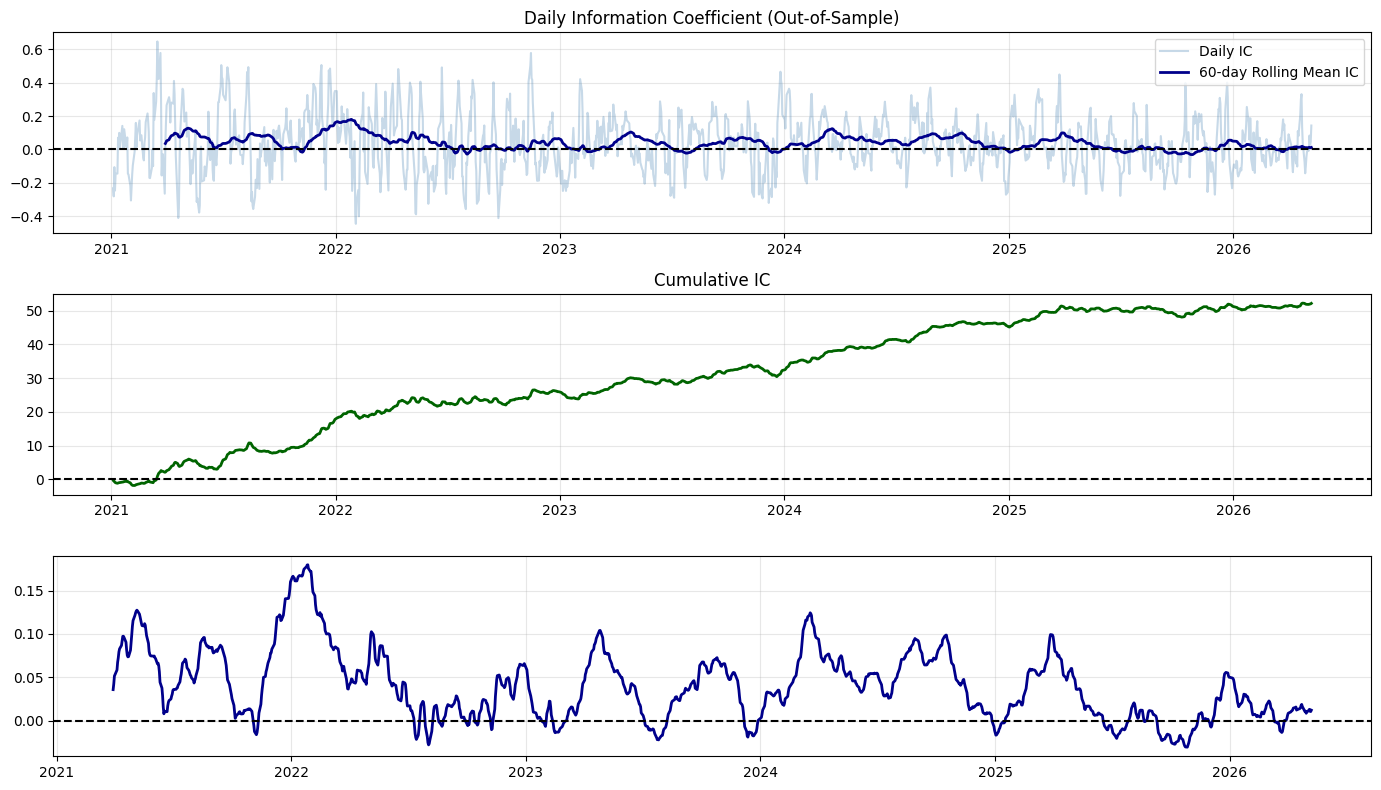

In [9]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# val_data already has 'prediction' and 'target' columns from earlier cells
ic_list = []
ic_dates = []

for date in val_dates:
    try:
        day_data = val_data.loc[date][['prediction', 'target']].dropna()
    except KeyError:
        continue
    if len(day_data) < 20:
        continue
    
    ic, _ = spearmanr(day_data['prediction'], day_data['target'])
    if not np.isnan(ic):
        ic_list.append(ic)
        ic_dates.append(date)

ic_series = pd.Series(ic_list, index=ic_dates)

# --- Summary Stats ---
print(f"Mean IC:      {ic_series.mean():.5f}")
print(f"IC Std:       {ic_series.std():.5f}")
print(f"IC IR:        {ic_series.mean() / ic_series.std():.5f}")
print(f"Hit Rate:     {(ic_series > 0).mean():.2%}")
print(f"IC t-stat:    {ic_series.mean() / (ic_series.std() / np.sqrt(len(ic_series))):.2f}")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

# Rolling IC
rolling_ic = ic_series.rolling(60).mean()
axes[0].plot(ic_series.index, ic_series.values, alpha=0.3, color='steelblue', label='Daily IC')
axes[0].plot(rolling_ic.index, rolling_ic.values, color='darkblue', linewidth=2, label='60-day Rolling Mean IC')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Daily Information Coefficient (Out-of-Sample)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative IC
axes[1].plot(ic_series.index, ic_series.cumsum().values, color='darkgreen', linewidth=2)
axes[1].set_title('Cumulative IC')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].grid(True, alpha=0.3)

axes[2].plot(rolling_ic.index, rolling_ic.values, color='darkblue', linewidth=2, label='60-day Rolling Mean IC')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
